In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from joblib import Parallel, delayed
from numba import njit
from sbi.utils import BoxUniform

from episbi import SBIEngine
from episbi.utils import plot_prediction_windows

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


In [2]:
observed_weekly = np.array([1, 0, 2, 5, 1, 2, 1, 1], dtype=np.float32)[:, None]
week_starts = pd.date_range("2026-04-06", periods=len(observed_weekly), freq="7D")

num_weeks = observed_weekly.shape[0]
total_days = 7 * num_weeks
population = 149

r0_lower = 0.5
r0_upper = 3.0
parameter_names = ["R0", "E1_0", "E3_0"]
discrete_states = [(e1, e3) for e1 in (0, 1) for e3 in (0, 1, 2)]

num_simulations = 1_000
num_samples = 1_000
r0_grid_size = 500
n_jobs = -1
seed = 0
device = "cuda" if torch.cuda.is_available() else "cpu"

## Data

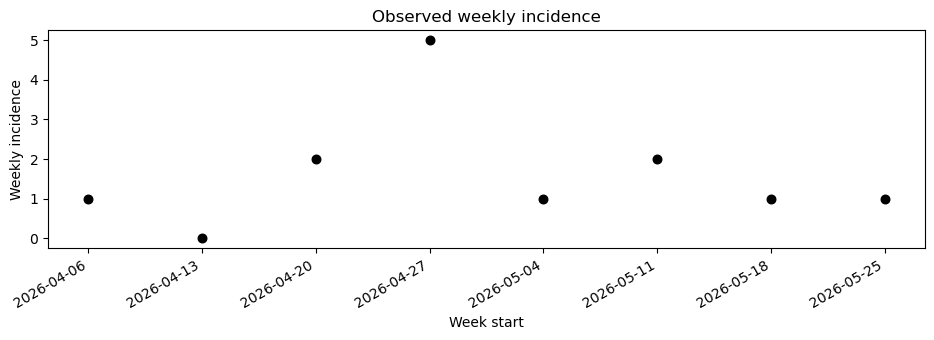

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 3.5))
ax.scatter(week_starts, observed_weekly[:, 0], color="black", s=38)
ax.set_title("Observed weekly incidence")
ax.set_xlabel("Week start")
ax.set_ylabel("Weekly incidence")
ax.set_xticks(week_starts)
fig.autofmt_xdate(rotation=30, ha="right")
fig.tight_layout()
plt.show()

## Simulator

In [11]:
@njit
def poisson_event(mean, available):
    mean = max(0.0, float(mean))
    available = max(0, int(available))
    draw = np.random.poisson(mean)
    return min(available, int(draw))


@njit
def stochastic_se1e2e3ir(r0, e1_0, e3_0,
    seed, total_days, population, num_weeks, 
    dt=0.01, incubation_mean=18.0, infectious_mean=8.0, intervention_day=35, post_intervention_r=0.96):
    
    if seed >= 0:
        np.random.seed(seed)

    gamma = 1.0 / infectious_mean
    sigma = 3.0 / incubation_mean

    e1 = int(round(e1_0))
    e2 = 0
    e3 = int(round(e3_0))
    i = 0
    r = 0
    s = int(population) - e1 - e2 - e3 - i - r

    daily_cases = np.zeros(total_days, dtype=np.float32)
    weekly = np.zeros(num_weeks, dtype=np.float32)
    steps = int(np.ceil(total_days / dt))

    for step in range(steps):
        t = step * dt
        day = int(np.floor(t))
        if day >= total_days:
            day = total_days - 1

        if t >= intervention_day:
            beta = post_intervention_r * gamma
        else:
            beta = r0 * gamma

        n = max(1, s + e1 + e2 + e3 + i + r)

        new_exposed = poisson_event(beta * s * i / n * dt, s)
        e1_to_e2 = poisson_event(sigma * e1 * dt, e1)
        e2_to_e3 = poisson_event(sigma * e2 * dt, e2)
        e3_to_i = poisson_event(sigma * e3 * dt, e3)
        i_to_r = poisson_event(gamma * i * dt, i)

        s -= new_exposed
        e1 += new_exposed - e1_to_e2
        e2 += e1_to_e2 - e2_to_e3
        e3 += e2_to_e3 - e3_to_i
        i += e3_to_i - i_to_r
        r += i_to_r

        daily_cases[day] += e3_to_i

    for day in range(total_days):
        week = day // 7
        if week < num_weeks:
            weekly[week] += daily_cases[day]

    return weekly

In [12]:
def sample_prior(num_simulations, seed=0):
    rng = np.random.default_rng(seed)
    r0 = rng.uniform(r0_lower, r0_upper, size=num_simulations)
    e1 = rng.integers(0, 2, size=num_simulations)
    e3 = rng.integers(0, 3, size=num_simulations)
    return np.column_stack([r0, e1, e3]).astype(np.float32)


def simulate_one(theta, seed=None):
    r0, e1, e3 = np.asarray(theta, dtype=np.float32)
    sim_seed = -1 if seed is None else int(seed)
    weekly = stochastic_se1e2e3ir(float(r0), float(e1),float(e3),
        sim_seed, total_days, population, num_weeks,
        0.01, 18.0, 8.0, 35.0, 0.96)
    return weekly[:, None].astype(np.float32)


_ = simulate_one([1.0, 0, 0], seed=seed)

In [13]:
rng = np.random.default_rng(seed)
thetas = sample_prior(num_simulations, seed=seed)
seeds = rng.integers(0, 2**32 - 1, size=num_simulations, dtype=np.uint32)

xs = Parallel(n_jobs=n_jobs, verbose=10)(
    delayed(simulate_one)(theta, int(sim_seed))
    for theta, sim_seed in zip(thetas, seeds)
)
xs = np.stack(xs).astype(np.float32)

thetas.shape, xs.shape, observed_weekly.shape

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19419558974068984s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.04642295837402344s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  77 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 106 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.06018996238708496s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 143 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.07933402061462402s.) Set

((1000, 3), (1000, 8, 1), (8, 1))

## Inference - NPE

In [14]:
support_prior = BoxUniform(
    low=torch.tensor([r0_lower, -0.49, -0.49], dtype=torch.float32, device=device),
    high=torch.tensor([r0_upper, 1.49, 2.49], dtype=torch.float32, device=device),
)

theta_train = torch.as_tensor(thetas, dtype=torch.float32, device=device)
x_train = torch.as_tensor(xs[:, :, 0], dtype=torch.float32, device=device)
x_obs = torch.as_tensor(observed_weekly[:, 0], dtype=torch.float32, device=device)

theta_train.shape, x_train.shape, x_obs.shape

(torch.Size([1000, 3]), torch.Size([1000, 8]), torch.Size([8]))

In [15]:
engine = SBIEngine(batch_size=256, device=device)
nre_result = engine.run_nre(
    obs_data=x_obs,
    prior=support_prior,
    thetas=theta_train,
    xs=x_train,
    show_train_summary=False,
)

posterior = nre_result["posterior"]
x_obs_tensor = nre_result["x_obs"]

[*] Running NRE with batch size 256...
 Neural network successfully converged after 63 epochs.

/home/gjang12/.conda/envs/sbi_env/lib/python3.11/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


In [16]:
def evaluate_nre_grid(posterior, x_obs_tensor):
    rows = []
    r0_grid = np.linspace(r0_lower, r0_upper, r0_grid_size, dtype=np.float32)

    for e1, e3 in discrete_states:
        theta_grid = np.column_stack(
            [
                r0_grid,
                np.full_like(r0_grid, e1, dtype=np.float32),
                np.full_like(r0_grid, e3, dtype=np.float32),
            ]
        ).astype(np.float32)
        theta_grid_t = torch.as_tensor(theta_grid, dtype=torch.float32, device=device)

        with torch.no_grad():
            log_score = posterior.potential(theta_grid_t, x=x_obs_tensor).detach().cpu().numpy()

        for r0, score in zip(r0_grid, log_score):
            rows.append({"R0": float(r0), "E1_0": int(e1), "E3_0": int(e3), "log_score": float(score)})

    grid_df = pd.DataFrame(rows)
    max_score = grid_df["log_score"].max()
    grid_df["weight"] = np.exp(grid_df["log_score"] - max_score)
    grid_df["posterior_prob"] = grid_df["weight"] / grid_df["weight"].sum()
    return grid_df


grid_df = evaluate_nre_grid(posterior, x_obs_tensor)
state_posterior = (
    grid_df.groupby(["E1_0", "E3_0"], as_index=False)["posterior_prob"]
    .sum()
    .sort_values("posterior_prob", ascending=False)
)

posterior_samples = grid_df.sample(
    n=num_samples,
    replace=True,
    weights="posterior_prob",
    random_state=seed,
).reset_index(drop=True)[parameter_names + ["posterior_prob"]]

state_posterior

,E1_0,E3_0,posterior_prob
2,0,2,0.501637
5,1,2,0.204523
4,1,1,0.166494
1,0,1,0.107371
3,1,0,0.016660
0,0,0,0.003317


In [17]:
posterior_samples["R0"].describe(percentiles=[0.025, 0.5, 0.975])

count    1000.000000
mean        2.037846
std         0.645121
min         0.500000
2.5%        0.645165
50%         2.150802
97.5%       2.954910
max         2.994990
Name: R0, dtype: float64

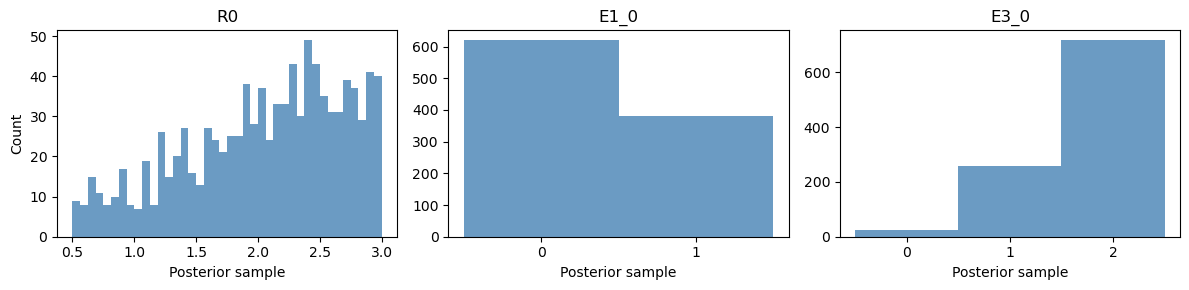

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].hist(posterior_samples["R0"], bins=40, color="steelblue", alpha=0.8)
axes[0].set_title("R0")
axes[0].set_xlabel("Posterior sample")
axes[0].set_ylabel("Count")

axes[1].hist(posterior_samples["E1_0"], bins=np.arange(-0.5, 2.5, 1), color="steelblue", alpha=0.8)
axes[1].set_xticks([0, 1])
axes[1].set_title("E1_0")
axes[1].set_xlabel("Posterior sample")

axes[2].hist(posterior_samples["E3_0"], bins=np.arange(-0.5, 3.5, 1), color="steelblue", alpha=0.8)
axes[2].set_xticks([0, 1, 2])
axes[2].set_title("E3_0")
axes[2].set_xlabel("Posterior sample")

fig.tight_layout()
plt.show()

In [19]:
def posterior_predictive(samples_df, num_curves=100, seed=0):
    rng = np.random.default_rng(seed)
    draw_ids = rng.choice(len(samples_df), size=min(num_curves, len(samples_df)), replace=False)
    curves = []
    for draw_id in draw_ids:
        theta = samples_df.iloc[draw_id]
        curve = simulate_one(
            [theta.R0, theta.E1_0, theta.E3_0],
            seed=int(rng.integers(0, 2**32 - 1)),
        )[:, 0]
        curves.append(curve)
    return np.stack(curves).astype(np.float32)


ppc = posterior_predictive(posterior_samples)
q05, q50, q95 = np.quantile(ppc, [0.05, 0.5, 0.95], axis=0)

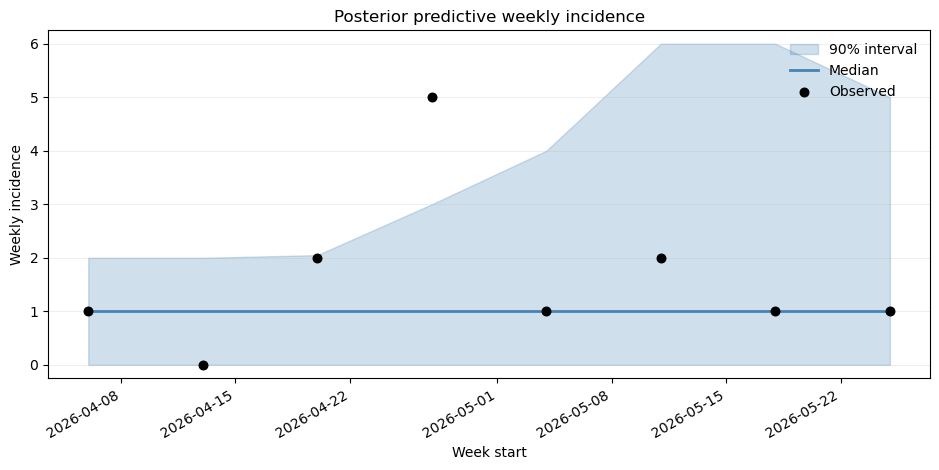

In [20]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))

ax.fill_between(week_starts, q05, q95, color="steelblue", alpha=0.25, label="90% interval")
ax.plot(week_starts, q50, color="steelblue", linewidth=2.0, label="Median")
ax.scatter(week_starts, observed_weekly[:, 0], color="black", s=38, zorder=4, label="Observed")

ax.set_title("Posterior predictive weekly incidence")
ax.set_xlabel("Week start")
ax.set_ylabel("Weekly incidence")
ax.set_ylim(-0.25, max(5.25, float(np.nanmax(q95)) + 0.25))
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.legend(frameon=False, loc="upper right")

fig.autofmt_xdate(rotation=30, ha="right")
fig.tight_layout()
plt.show()